# causal-ai API Tutorial

This tutorial covers the Python API for researchers who want to integrate `causal-ai` into their own scripts, extend the framework, or perform custom analysis beyond what the CLI provides.

For a simpler introduction using just terminal commands, see `tutorial_cli.ipynb`.

For help defining your causal DAG and generating test cases, see the [Causal Testing Framework documentation](https://causal-testing-framework.readthedocs.io/en/latest/?badge=latest).

In [1]:
import sys
from pathlib import Path

repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

---

## 1. Data Collection

`PyKaleCausalDataCollector` instruments existing [PyKale](https://pykale.github.io/) training scripts to record:

- **Input variables (causes):** hyperparameters, precision settings, optimiser, batch size, seed
- **Output variables (effects):** accuracy, loss, training time, GPU memory

Each run calls the same sequence: `log_config` → `start_timer` / `end_timer` → `log_metrics` → `log_memory_usage` → `save_run`. Once all runs are complete, `export_data` writes everything to CSV.

In practice this loop runs over a full parameter grid on an HPC cluster (see, e.g. `examples/action_dann/action_dann_data_collector.py`). The example below uses synthetic data to illustrate the API.

In [2]:
import tempfile
import time
import pandas as pd
from pathlib import Path

from causal_ai import PyKaleCausalDataCollector

tmp_dir = Path(tempfile.mkdtemp())
output_csv = tmp_dir / "runtime_data.csv"

collector = PyKaleCausalDataCollector(str(output_csv))

param_grid = [
    {"fp_precision": "fp16", "batch_size": 32, "learning_rate": 1e-3, "optimiser_type": "AdamW", "seed": 42},
    {"fp_precision": "fp32", "batch_size": 32, "learning_rate": 1e-3, "optimiser_type": "AdamW", "seed": 42},
    {"fp_precision": "fp16", "batch_size": 64, "learning_rate": 3e-4, "optimiser_type": "SGD",   "seed": 7},
    {"fp_precision": "fp32", "batch_size": 64, "learning_rate": 3e-4, "optimiser_type": "SGD",   "seed": 7},
]

for run_id, params in enumerate(param_grid):
    # 1. Log the configuration (causes)
    collector.log_config({**params, "run_id": run_id})

    # 2. Time the training
    collector.start_timer("training")
    time.sleep(0.02)
    training_time = collector.end_timer("training")

    # 3. Log outcome metrics (effects)
    gpu_mem = 2048.0 if params["fp_precision"] == "fp16" else 4096.0
    collector.log_metrics({
        "test_target_acc": 0.90 + (0.02 if params["fp_precision"] == "fp32" else 0.0),
        "training_time_seconds": training_time,
    })

    # 4. Log memory usage
    collector.log_memory_usage(gpu_mem, device="gpu")

    # 5. Save this run
    collector.save_run()

# 6. Export all runs to CSV
collector.export_data()

demo_df = pd.read_csv(output_csv)
demo_df

,fp_precision,batch_size,learning_rate,optimiser_type,seed,run_id,training_time_seconds,test_target_acc,gpu_memory_peak_mb
0,fp16,32,0.0010,AdamW,42,0,0.023530,0.90,2048.0
1,fp32,32,0.0010,AdamW,42,1,0.031359,0.92,4096.0
2,fp16,64,0.0003,SGD,7,2,0.030468,0.90,2048.0
3,fp32,64,0.0003,SGD,7,3,0.030961,0.92,4096.0


---

## 2. Merging Parallel HPC Job Outputs

When running large parameter sweeps, each SLURM job writes its own CSV. `merge_csv_files` combines them into a single dataset sorted by `run_id`.

In [3]:
from causal_ai import merge_csv_files

# Simulate per-job CSVs
jobs_dir = tmp_dir / "jobs"
jobs_dir.mkdir()

pd.DataFrame([{"run_id": 0, "batch_size": 16, "test_target_acc": 0.88}]).to_csv(
    jobs_dir / "results_job000.csv", index=False
)
pd.DataFrame([{"run_id": 1, "batch_size": 32, "test_target_acc": 0.91}]).to_csv(
    jobs_dir / "results_job001.csv", index=False
)

merged = merge_csv_files(jobs_dir)
print(f"Merged {len(merged)} runs from {len(list(jobs_dir.glob('*.csv')))} files")
merged

Merged 2 runs from 2 files


,run_id,batch_size,test_target_acc
0,0,16,0.88
1,1,32,0.91


In practice:

```python
merged = merge_csv_files(Path("examples/action_dann/data/production"))
merged.to_csv("examples/action_dann/data/merged.csv", index=False)
```

---

## 3. Loading Causal Testing Artifacts

`load_cluster_data` auto-discovers all four artefacts from a directory and returns them as a dictionary.

| Key | Content |
|-----|---------|
| `dag` | DOT source string |
| `tests` | List of test definition dicts |
| `results` | List of test result dicts |
| `runtime_data` | pandas DataFrame of observations |

In [4]:
from causal_ai.utils import load_cluster_data

stanage_dir = repo_root / "examples" / "action_dann" / "data" / "stanage"

artifacts = load_cluster_data(stanage_dir)
print("Loaded:", list(artifacts.keys()))

Loaded: ['dag', 'tests', 'results', 'runtime_data']


### 3a. Explore the Runtime Data

In [5]:
df = artifacts["runtime_data"]
print(f"Shape: {df.shape}")
df.head()

Shape: (960, 31)


,learning_rate,batch_size,optimiser_type,adaptation_method,seed,fp_precision,run_id,model_method,image_modality,domain_pair,...,test_loss,test_task_loss,test_domain_div_loss,test_source_acc,test_target_acc,test_domain_acc,memory_peak_mb,gpu_memory_peak_mb,test_source_domain_acc,test_target_domain_acc
0,0.100,16,SGD,DAN,2023,bf16-mixed,0,i3d,rgb,EPIC_D1_D2,...,1.848469,1.617943,0.230547,0.388587,0.273098,0.230547,903.585938,4646.157715,NaN,NaN
1,0.100,16,SGD,DAN,1,fp16-mixed,1,i3d,rgb,EPIC_D1_D2,...,1.817820,1.668016,0.149818,0.392663,0.239130,0.149818,649.292969,4649.359863,NaN,NaN
2,0.001,32,AdamW,CDAN,123,bf16-mixed,2,i3d,rgb,EPIC_D1_D2,...,2.925191,1.460175,1.465152,0.442935,0.241848,0.470109,294.683594,9160.876953,0.889946,0.050272
3,0.001,4,AdamW,DAN,2023,fp32-true,3,i3d,rgb,EPIC_D1_D2,...,2.799667,1.777627,1.022134,0.322193,0.200535,1.022134,122.164062,2271.006348,NaN,NaN
4,0.100,16,SGD,CDAN,1,fp32-true,4,i3d,rgb,EPIC_D1_D2,...,3.523253,1.937024,1.586375,0.323370,0.296196,0.498641,817.468750,7809.911621,0.002717,0.994565


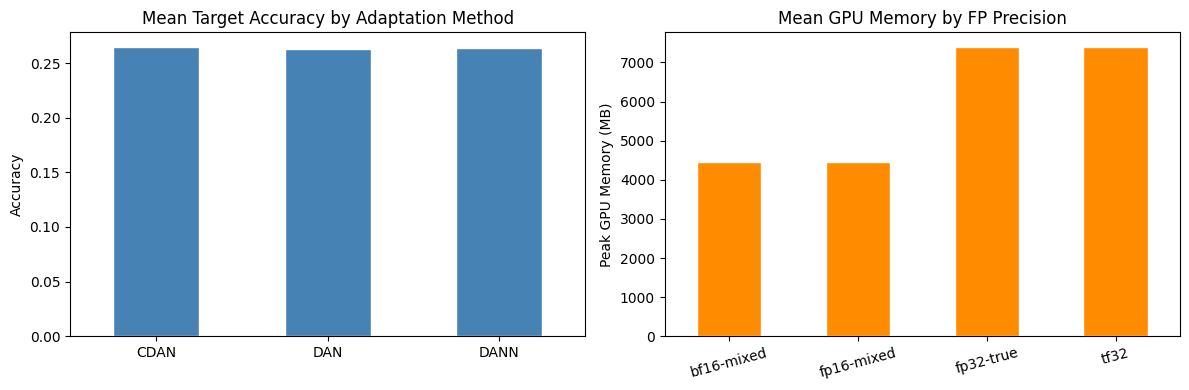

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("adaptation_method")["test_target_acc"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Mean Target Accuracy by Adaptation Method")
axes[0].set_ylabel("Accuracy")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("fp_precision")["gpu_memory_peak_mb"].mean().plot(
    kind="bar", ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Mean GPU Memory by FP Precision")
axes[1].set_ylabel("Peak GPU Memory (MB)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 3b. Inspect a Causal Test Result

Each result contains the treatment, outcome, estimated causal effect, and 95% confidence interval.

In [7]:
import json

results = artifacts["results"]
print(f"Total causal tests: {len(results)}")
print("\nExample result:")
print(json.dumps(results[5], indent=2))

Total causal tests: 32

Example result:
{
  "name": "fp_precision --> gpu_memory_peak_mb",
  "estimate_type": "coefficient",
  "effect": "direct",
  "treatment_variable": "fp_precision",
  "expected_effect": {
    "gpu_memory_peak_mb": "SomeEffect"
  },
  "alpha": 0.05,
  "formula": "gpu_memory_peak_mb ~ fp_precision",
  "skip": false,
  "passed": true,
  "result": {
    "treatment": "fp_precision",
    "outcome": "gpu_memory_peak_mb",
    "adjustment_set": [],
    "effect_measure": "coefficient",
    "effect_estimate": {
      "fp_precision[T.fp16-mixed]": 3.4061055501482542,
      "fp_precision[T.fp32-true]": 2955.859698486331,
      "fp_precision[T.tf32]": 2950.166361490888
    },
    "ci_low": {
      "fp_precision[T.fp16-mixed]": -739.4512156154608,
      "fp_precision[T.fp32-true]": 2213.0023773207217,
      "fp_precision[T.tf32]": 2207.30904032528
    },
    "ci_high": {
      "fp_precision[T.fp16-mixed]": 746.2634267157573,
      "fp_precision[T.fp32-true]": 3698.7170196519405,

---

## 4. Summarising Results

In [8]:
from causal_ai.utils import summarise_results

summary = summarise_results(results)

print(f"Total:   {summary['total']}")
print(f"Passed:  {summary['passed']}")
print(f"Failed:  {summary['failed_count']}")
print(f"Skipped: {summary['skipped_count']}")

if summary["failed_tests"]:
    print("\nFailed tests:")
    for name in summary["failed_tests"]:
        print(f"  - {name}")

Total:   32
Passed:  24
Failed:  8
Skipped: 0

Failed tests:
  - seed _||_ test_target_acc
  - fp_precision --> test_target_acc
  - fp_precision --> test_source_acc
  - training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']
  - batch_size --> training_time_seconds
  - optimiser_type --> training_time_seconds
  - batch_size --> evaluation_time_seconds
  - adaptation_method --> test_target_acc


The full summary dict is JSON-serialisable. This is useful for saving reports or feeding into downstream pipelines:

In [10]:
print(json.dumps(summary, indent=2))

{
  "total": 32,
  "passed": 24,
  "failed_count": 8,
  "skipped_count": 0,
  "failed_tests": [
    "seed _||_ test_target_acc",
    "fp_precision --> test_target_acc",
    "fp_precision --> test_source_acc",
    "training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']",
    "batch_size --> training_time_seconds",
    "optimiser_type --> training_time_seconds",
    "batch_size --> evaluation_time_seconds",
    "adaptation_method --> test_target_acc"
  ],
  "skipped_tests": []
}


---

## 5. Cross-Cluster Comparison

`compare_clusters` identifies **divergent tests** — hypotheses that passed on one cluster but failed on another, revealing platform-dependent effects.

In [11]:
from causal_ai.utils import compare_clusters

bede_dir = repo_root / "examples" / "action_dann" / "data" / "bede"
bede_results = load_cluster_data(bede_dir)["results"]

comparison = compare_clusters({
    "stanage": results,
    "bede": bede_results,
})

for cluster, s in comparison["per_cluster"].items():
    print(f"[{cluster}]  Passed: {s['passed']}  Failed: {s['failed_count']}  Skipped: {s['skipped_count']}")

print()
if comparison["divergent_tests"]:
    print("Divergent tests (passed on one cluster, failed on another):")
    for t in comparison["divergent_tests"]:
        print(f"  - {t}")
else:
    print("No divergent tests — both clusters agree on all outcomes.")

[stanage]  Passed: 24  Failed: 8  Skipped: 0
[bede]  Passed: 22  Failed: 10  Skipped: 0

Divergent tests (passed on one cluster, failed on another):
  - batch_size --> evaluation_time_seconds
  - batch_size --> test_target_acc
  - batch_size --> training_time_seconds
  - fp_precision --> evaluation_time_seconds
  - fp_precision --> training_time_seconds
  - training_time_seconds _||_ evaluation_time_seconds | ['batch_size', 'fp_precision']
  - training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']
  - training_time_seconds _||_ test_source_acc | ['batch_size', 'fp_precision', 'optimiser_type']


---

## 6. Visualising Results

In [12]:
from IPython.display import Image, display
from causal_ai.utils import visualise_results

dag_path     = stanage_dir / "dag.dot"
results_path = stanage_dir / "causal_test_results_stanage.json"
output_dir   = repo_root / "output" / "visualisations"

visualise_results(dag_path, results_path, output_dir)

Saved 32 individual test plots to C:\Users\cs1fxa\PycharmProjects\causal-ai\output\visualisations\causal_tests/
Saved summary heatmap to C:\Users\cs1fxa\PycharmProjects\causal-ai\output\visualisations\summary.png


WindowsPath('C:/Users/cs1fxa/PycharmProjects/causal-ai/output/visualisations')

Summary heatmap:


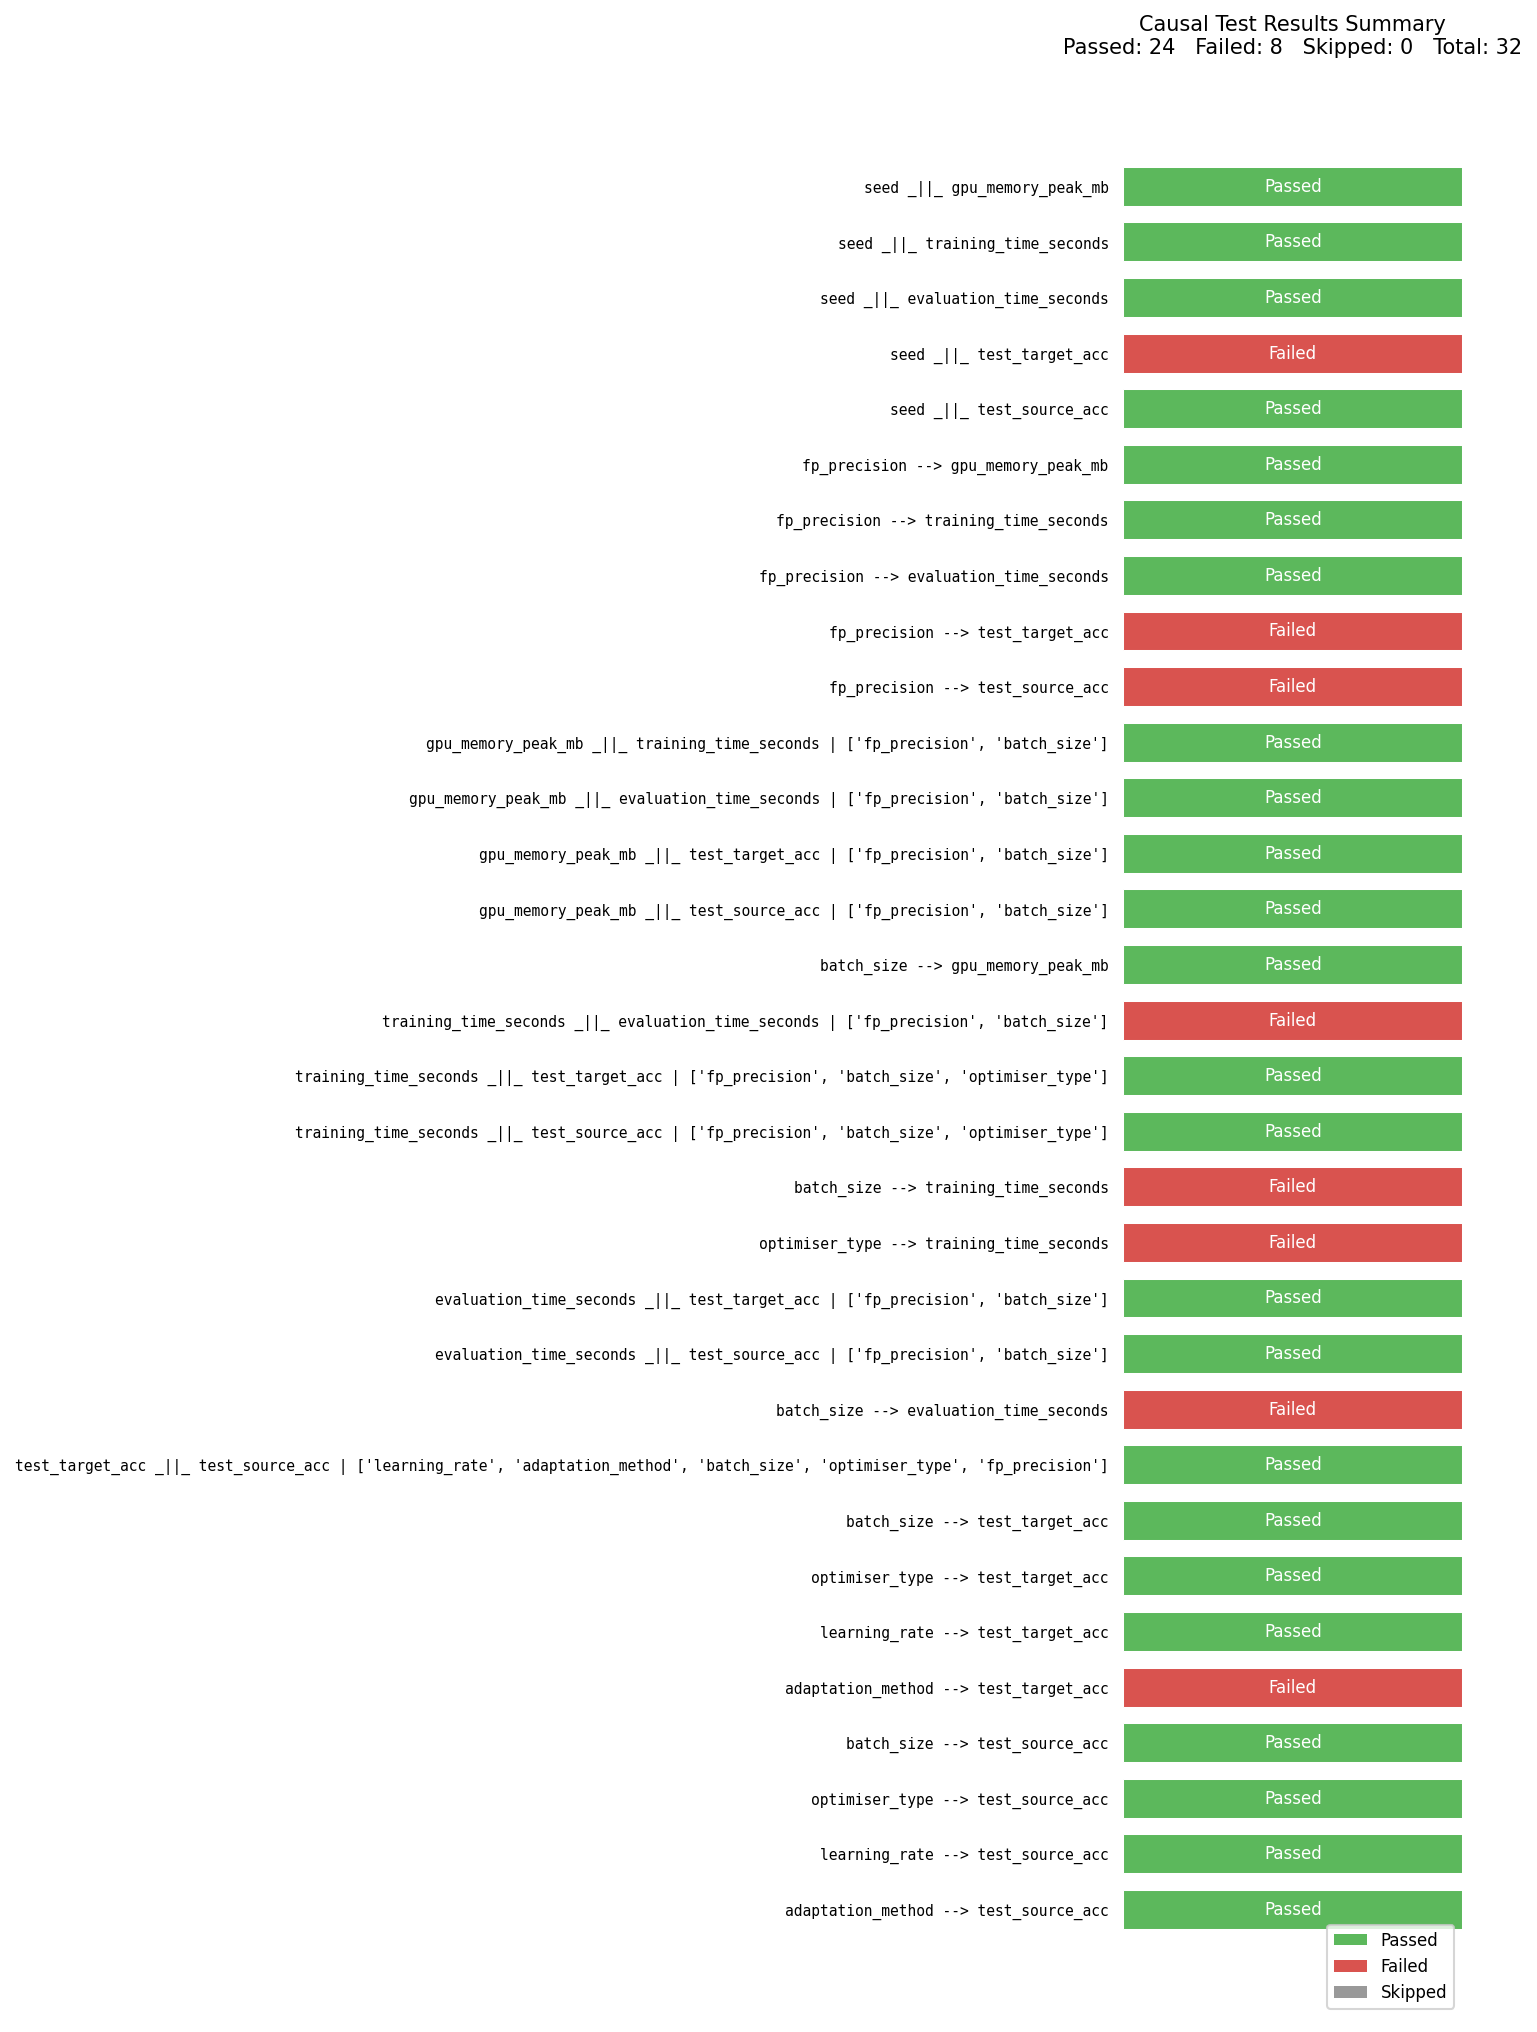

In [13]:
print("Summary heatmap:")
display(Image(filename=str(output_dir / "summary.png")))

35 individual test plots generated. Example:


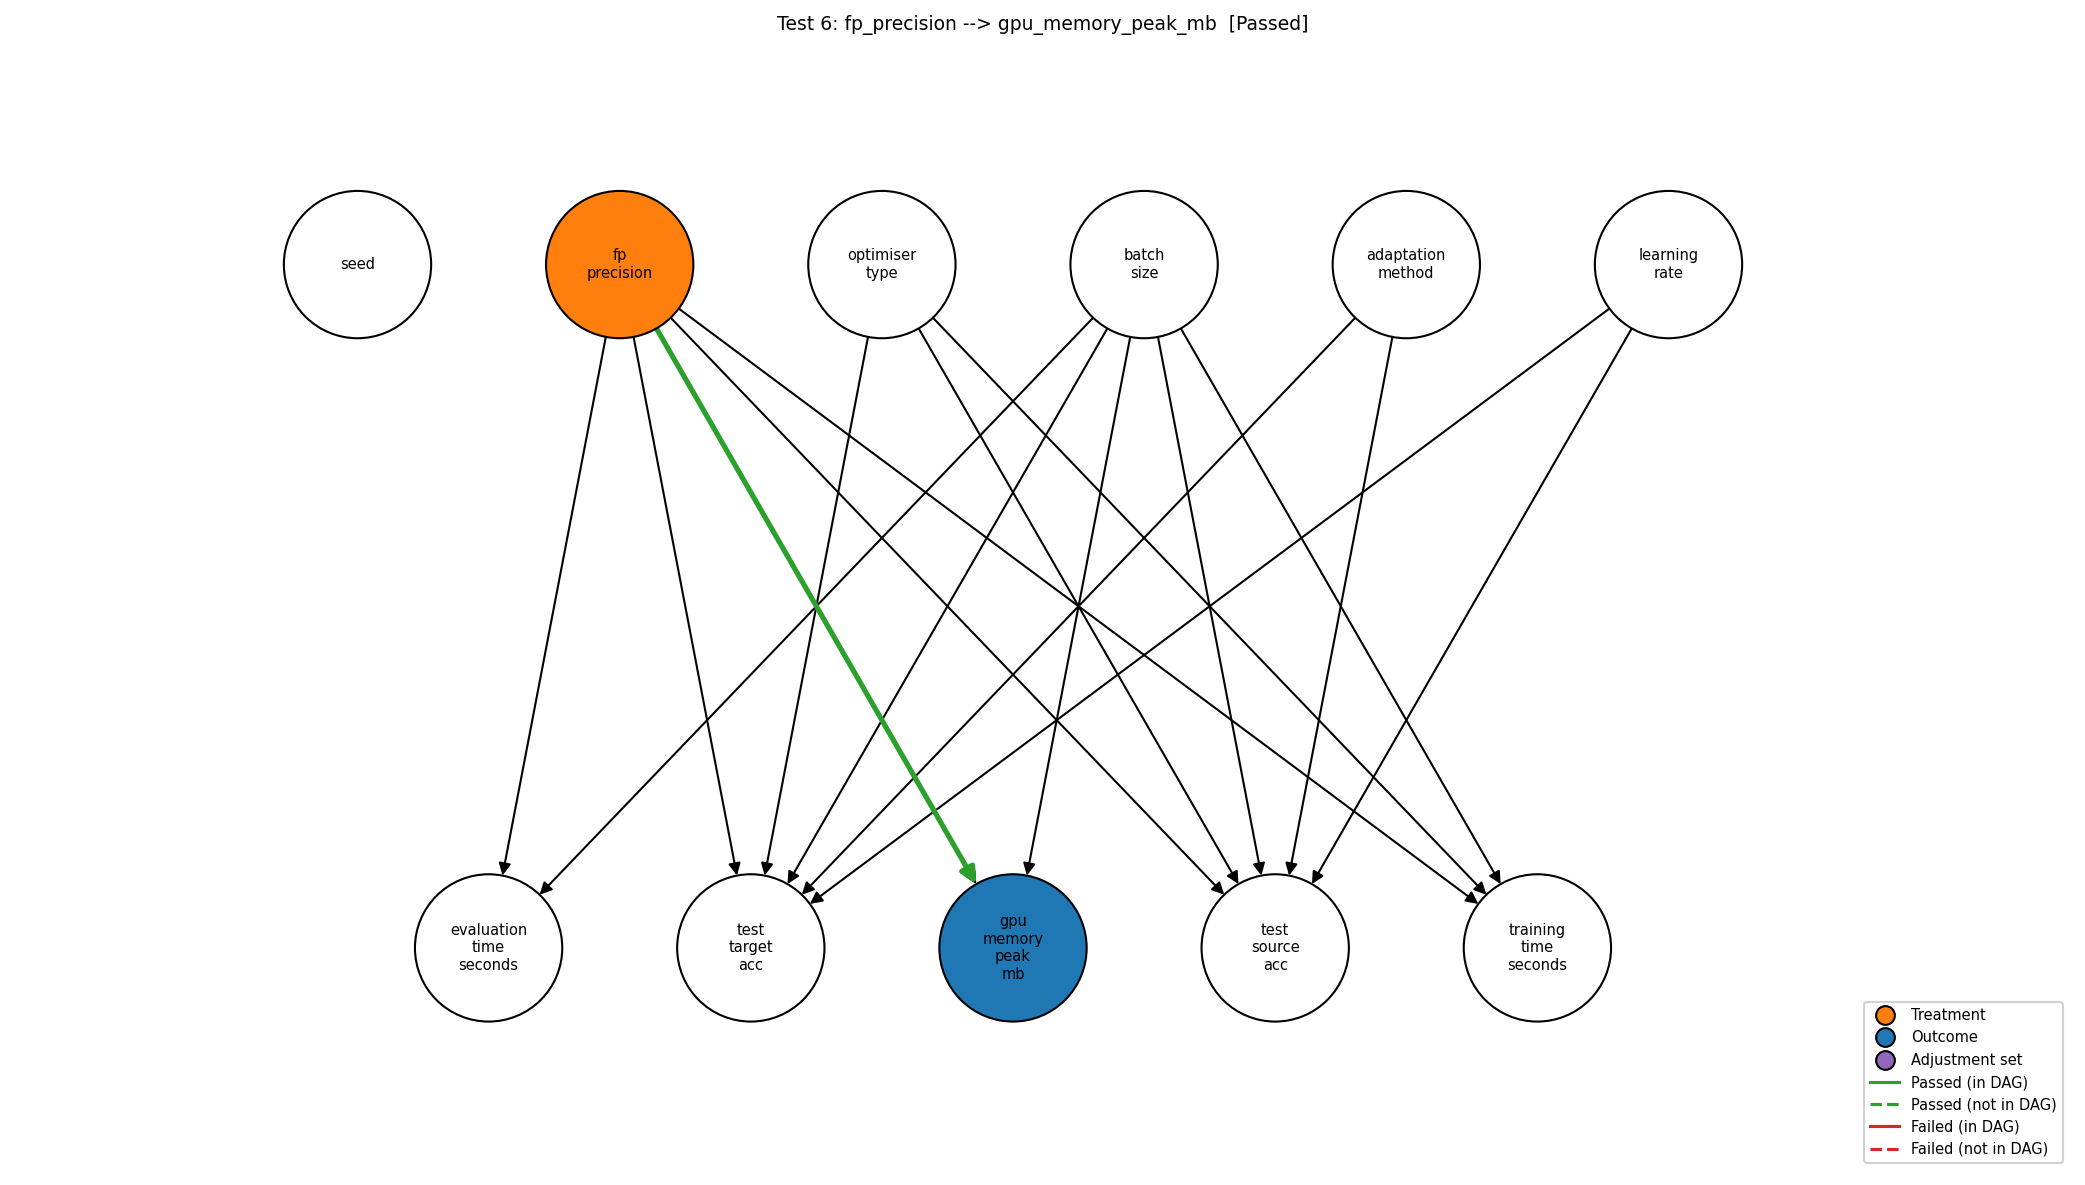

In [14]:
test_plots = sorted((output_dir / "causal_tests").glob("*.png"))
print(f"{len(test_plots)} individual test plots generated. Example:")
display(Image(filename=str(test_plots[5])))

---

## 7. Next Steps

| Task | Where to look |
|------|---------------|
| Instrument your own AI/ML pipeline | Copy a data collector from `examples/` and adapt `get_base_config()` and `run_single_experiment()` |
| Define your causal DAG and generate the causal tests | [CTF documentation](https://causal-testing-framework.readthedocs.io/en/latest/?badge=latest) |
| Run on your HPC system | `examples/digits_dann/` (images) or `examples/action_dann/` (video) |
| Multi-source adaptation | `examples/office_multisource_adapt/` |
| CLI-only usage | See `tutorial_cli.ipynb` |